ЧАСТЬ 1: ГЕНЕТИЧЕСКИЙ АЛГОРИТМ ДЛЯ ЗАДАЧИ КОММИВОЯЖЁРА

Начальная популяция:
  1. Маршрут: 1 -> 3 -> 2 -> 4 -> 5 -> 1, Длина: 30
  2. Маршрут: 3 -> 5 -> 4 -> 2 -> 1 -> 3, Длина: 23
  3. Маршрут: 4 -> 2 -> 3 -> 5 -> 1 -> 4, Длина: 27
  4. Маршрут: 3 -> 1 -> 4 -> 2 -> 5 -> 3, Длина: 25
  Поколение 1: Новый лучший маршрут! Длина: 23

Лучший найденный маршрут после 100 поколений:
  3 -> 5 -> 1 -> 2 -> 4 -> 3
Длина лучшего маршрута: 18


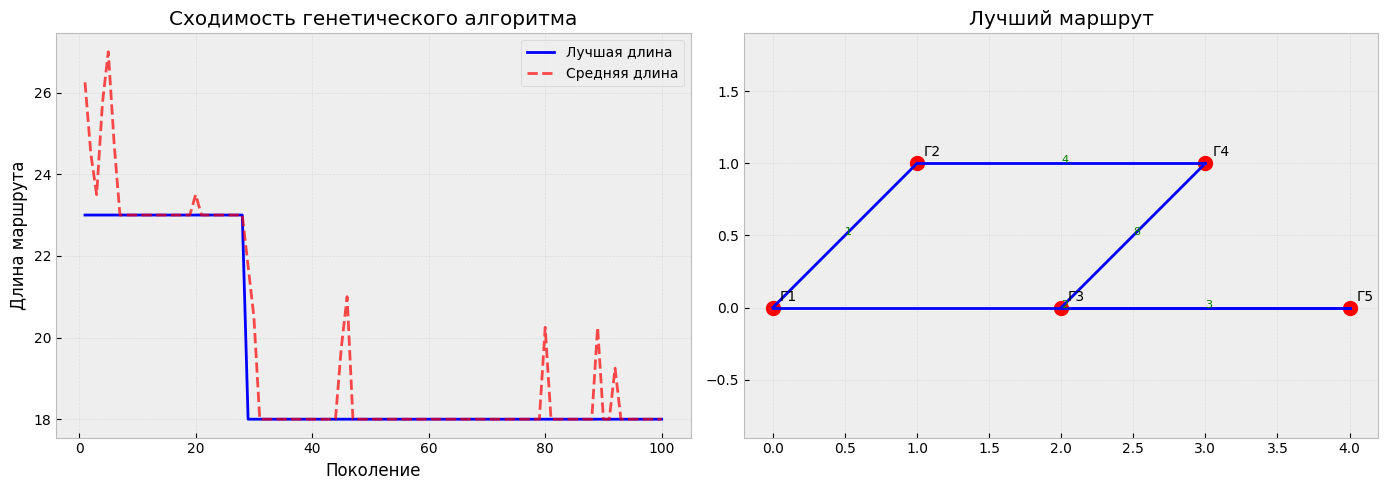


ЧАСТЬ 2: МУРАВЬИНЫЙ АЛГОРИТМ ДЛЯ ПОИСКА ПУТИ
Итерация 1/10: Лучшая длина: 32, Средняя длина: 42.6, Успешных муравьев: 95/100
Итерация 2/10: Лучшая длина: 32, Средняя длина: 34.2, Успешных муравьев: 100/100
Итерация 3/10: Лучшая длина: 32, Средняя длина: 32.7, Успешных муравьев: 100/100
Итерация 4/10: Лучшая длина: 32, Средняя длина: 33.2, Успешных муравьев: 100/100
Итерация 5/10: Лучшая длина: 32, Средняя длина: 32.1, Успешных муравьев: 100/100
Итерация 6/10: Лучшая длина: 32, Средняя длина: 32.3, Успешных муравьев: 100/100
Итерация 7/10: Лучшая длина: 32, Средняя длина: 32.3, Успешных муравьев: 100/100
Итерация 8/10: Лучшая длина: 32, Средняя длина: 32.0, Успешных муравьев: 100/100
Итерация 9/10: Лучшая длина: 32, Средняя длина: 32.0, Успешных муравьев: 100/100
Итерация 10/10: Лучшая длина: 32, Средняя длина: 32.1, Успешных муравьев: 100/100

Лучший найденный путь: A -> E -> C -> D -> G
Длина лучшего пути: 32
Длина лучшего пути: 32


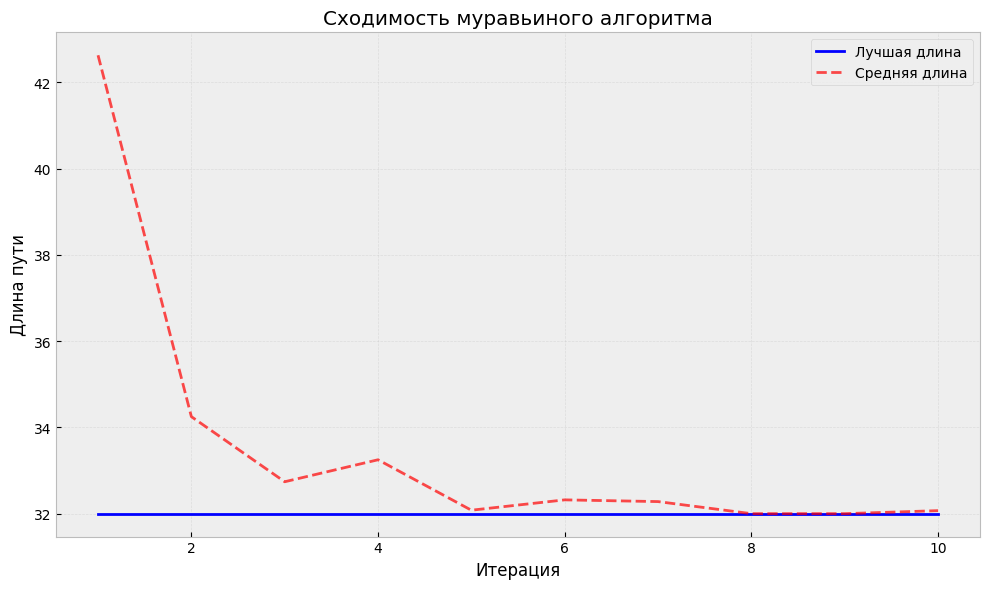


ИТОГОВОЕ СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Метод                              Результат           
-------------------------------------------------------
Генетический алгоритм (TSP)        18                  
Муравьиный алгоритм (Path)         32                  


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Настройка визуализации
plt.style.use('bmh')
plt.rc('xtick', labelsize=10); plt.rc('ytick', labelsize=10)

# ==========================================
# ЧАСТЬ 1. ГЕНЕТИЧЕСКИЙ АЛГОРИТМ (ЗАДАЧА КОММИВОЯЖЁРА)
# ==========================================
print("=" * 60)
print("ЧАСТЬ 1: ГЕНЕТИЧЕСКИЙ АЛГОРИТМ ДЛЯ ЗАДАЧИ КОММИВОЯЖЁРА")
print("=" * 60)

# Матрица расстояний (Вариант 1)
DIST_MATRIX = np.array([
    [0, 1, 5, 9, 2],
    [1, 0, 9, 4, 4],
    [5, 9, 0, 8, 3],
    [9, 4, 8, 0, 10],
    [2, 4, 3, 10, 0]
])

CITY_NAMES = ['Город 1', 'Город 2', 'Город 3', 'Город 4', 'Город 5']
N_CITIES = len(DIST_MATRIX)
POP_SIZE = 4 # число особей, увеличить для стабилизации
MUTATION_RATE = 0.01 # вероятность мутации
GENERATIONS = 100 # количество поколений
ELITISM_COUNT = 1 # число особей, попадающих в новое поколение без скрещивания и мутаций


def calculate_route_length(route):
    """Вычисляет длину замкнутого маршрута."""
    length = 0
    for i in range(len(route)):
        from_city = route[i]
        to_city = route[(i + 1) % len(route)]
        length += DIST_MATRIX[from_city][to_city]
    return length


def create_initial_population(pop_size, n_cities):
    """Создает начальную популяцию случайных перестановок."""
    return [random.sample(range(n_cities), n_cities) for _ in range(pop_size)]


def selection_roulette(population, fitness):
    """
    Оператор отбора (рулетка). Чем меньше длина маршрута, тем выше вероятность.
    Возвращает индексы двух разных родителей.
    """
    max_fitness = float(max(fitness))
    if max_fitness == min(fitness):
        probs = [1.0/len(fitness)] * len(fitness)
    else:
        inv_fitness: list[float] = [(max_fitness - float(f) + 1.0) for f in fitness]
        total_fitness = sum(inv_fitness)
        probs = [f / total_fitness for f in inv_fitness]

    idx1 = np.random.choice(len(population), p=probs)
    idx2 = np.random.choice(len(population), p=probs)
    while idx2 == idx1 and len(population) > 1:
        idx2 = np.random.choice(len(population), p=probs)
    return idx1, idx2


def crossover_tsp(parent1, parent2):
    """
    Специальный оператор скрещивания для перестановок (Order Crossover - OX).
    Сохраняет относительный порядок генов.
    """
    size = len(parent1)
    point1, point2 = sorted(random.sample(range(size), 2))

    def ox_child(p1, p2):
        child = [-1] * size
        child[point1:point2+1] = p2[point1:point2+1]
        p1_remaining = [gene for gene in p1 if gene not in child]
        p1_idx = 0
        for i in range(size):
            if child[i] == -1:
                child[i] = p1_remaining[p1_idx]
                p1_idx += 1
        return child

    return ox_child(parent1, parent2), ox_child(parent2, parent1)


def mutation_swap(route, mutation_rate):
    """Мутация: обмен двух случайных городов."""
    mutated = route.copy()
    if random.random() < mutation_rate:
        idx1, idx2 = random.sample(range(len(route)), 2)
        mutated[idx1], mutated[idx2] = mutated[idx2], mutated[idx1]
    return mutated


def genetic_algorithm(generations=GENERATIONS, verbose=True):
    """Запускает генетический алгоритм."""
    best_overall_route = list()
    population = create_initial_population(POP_SIZE, N_CITIES)
    best_overall_length = float('inf')
    history_best = []
    history_avg = []

    if verbose:
        print("\nНачальная популяция:")
        for i, route in enumerate(population):
            length = calculate_route_length(route)
            route_str = ' -> '.join(str(c+1) for c in route) + f' -> {route[0]+1}'
            print(f"  {i+1}. Маршрут: {route_str}, Длина: {length}")

    for gen in range(generations):
        fitness = [calculate_route_length(route) for route in population]
        avg_length = sum(fitness) / len(fitness)
        history_avg.append(avg_length)

        min_idx = np.argmin(fitness)
        min_length = fitness[min_idx]

        if min_length < best_overall_length:
            best_overall_length = min_length
            best_overall_route = population[min_idx].copy()
            if verbose and gen % 10 == 0:
                ' -> '.join(str(c + 1) for c in best_overall_route) + f' -> {best_overall_route[0] + 1}'
                print(f"  Поколение {gen+1}: Новый лучший маршрут! Длина: {min_length}")

        history_best.append(min_length)

        new_population = [population[min_idx].copy()]  # элитизм

        while len(new_population) < POP_SIZE:
            p1_idx, p2_idx = selection_roulette(population, fitness)
            child1, child2 = crossover_tsp(population[p1_idx], population[p2_idx])
            child1 = mutation_swap(child1, MUTATION_RATE)
            child2 = mutation_swap(child2, MUTATION_RATE)
            new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        population = new_population

    if verbose:
        print(f"\nЛучший найденный маршрут после {generations} поколений:")
        route_str = ' -> '.join(str(c+1) for c in best_overall_route) + f' -> {best_overall_route[0]+1}'
        print(f"  {route_str}")
        print(f"Длина лучшего маршрута: {best_overall_length}")

    # Визуализация сходимости
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    generations_range = range(1, generations+1)

    ax1.plot(generations_range, history_best, 'b-', label='Лучшая длина')
    ax1.plot(generations_range, history_avg, 'r--', label='Средняя длина', alpha=0.7)
    ax1.set_title('Сходимость генетического алгоритма')
    ax1.set_xlabel('Поколение')
    ax1.set_ylabel('Длина маршрута')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Схематичное отображение лучшего маршрута
    cities_x = np.array(list(range(N_CITIES)))
    cities_y = np.array([i % 2 for i in range(N_CITIES)])
    for i in range(N_CITIES):
        ax2.plot(cities_x[i], cities_y[i], 'ro', markersize=10)
        ax2.annotate(f'Г{i+1}', (cities_x[i], cities_y[i]), xytext=(5, 5), textcoords='offset points')
    for i in range(N_CITIES):
        from_city = best_overall_route[i]
        to_city = best_overall_route[(i+1) % N_CITIES]
        ax2.plot([cities_x[from_city], cities_x[to_city]],
                 [cities_y[from_city], cities_y[to_city]], 'b-')
        mid_x = (cities_x[from_city] + cities_x[to_city]) / 2
        mid_y = (cities_y[from_city] + cities_y[to_city]) / 2
        dist_value = int(DIST_MATRIX[from_city][to_city])
        ax2.annotate(f'{dist_value}', (mid_x, mid_y),
                     color='green', fontsize=8)
    ax2.set_title('Лучший маршрут')
    ax2.axis('equal')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_overall_route, best_overall_length, history_best


best_route_ga, best_length_ga, _ = genetic_algorithm()


# ==========================================
# ЧАСТЬ 2. МУРАВЬИНЫЙ АЛГОРИТМ (ПОИСК ПУТИ В ГРАФЕ)
# ==========================================
print("\n" + "=" * 60)
print("ЧАСТЬ 2: МУРАВЬИНЫЙ АЛГОРИТМ ДЛЯ ПОИСКА ПУТИ")
print("=" * 60)

# Граф для Варианта 1
GRAPH = {
    'A': {'B': 17, 'E': 4, 'F': 7},
    'B': {'A': 17},
    'C': {'D': 6, 'E': 11, 'F': 15, 'G': 23},
    'D': {'C': 6, 'E': 17, 'G': 11},
    'E': {'A': 4, 'C': 11, 'D': 17},
    'F': {'A': 7, 'C': 15, 'G': 33},
    'G': {'C': 23, 'D': 11, 'F': 33}
}
START_NODE = 'A'
END_NODE = 'G'

# Параметры муравьиного алгоритма
N_ANTS = 100             # Количество муравьёв
N_ITERATIONS = 10        # Количество итераций (дней)
EVAPORATION_RATE = 0.1   # Коэффициент испарения феромона (ρ)
ALPHA = 1.0              # Важность феромона (α)
BETA = 2.0               # Важность эвристики (β)
Q = 80                   # Количество откладываемого феромона
INIT_PHEROMONE = 1.0     # Начальное значение феромона


def initialize_pheromone(graph, init_value):
    """Инициализирует феромон на всех ребрах графа."""
    pheromone = {}
    for node in graph:
        pheromone[node] = {}
        for neighbor in graph[node]:
            pheromone[node][neighbor] = init_value
    return pheromone


def calculate_path_length(path, graph):
    """Вычисляет длину пути в графе."""
    length = 0
    for i in range(len(path) - 1):
        length += graph[path[i]][path[i+1]]
    return length


def ant_colony_optimization():
    """Запускает муравьиный алгоритм."""
    pheromone = initialize_pheromone(GRAPH, INIT_PHEROMONE)

    best_path = None
    best_path_length = float('inf')
    history_best = []
    history_avg = []

    for iteration in range(N_ITERATIONS):
        paths = []
        path_lengths = []

        for ant in range(N_ANTS):
            path = [START_NODE]
            current_node = START_NODE
            visited = {START_NODE}

            while current_node != END_NODE:
                unvisited_neighbors = [n for n in GRAPH[current_node] if n not in visited]
                if not unvisited_neighbors:
                    break

                desirability = np.array([(1.0 / GRAPH[str(current_node)][str(n)])**BETA for n in unvisited_neighbors])
                pheromone_level = np.array([pheromone[current_node][n]**ALPHA for n in unvisited_neighbors])
                attractiveness = pheromone_level * desirability
                probs = attractiveness / attractiveness.sum()
                next_node = random.choices(unvisited_neighbors, weights=probs, k=1)[0]

                path.append(next_node)
                visited.add(next_node)
                current_node = next_node

            if path[-1] == END_NODE:
                path_len = calculate_path_length(path, GRAPH)
                paths.append(path)
                path_lengths.append(path_len)
                if path_len < best_path_length:
                    best_path_length = path_len
                    best_path = path.copy()

        # Испарение феромона
        for node in GRAPH:
            for neighbor in GRAPH[node]:
                pheromone[node][neighbor] *= (1 - EVAPORATION_RATE)
                pheromone[node][neighbor] = max(pheromone[node][neighbor], 0.01)

        # Откладывание феромона успешными муравьями
        for i, path in enumerate(paths):
            deposit = Q / path_lengths[i]
            for j in range(len(path) - 1):
                u, v = path[j], path[j+1]
                pheromone[u][v] += deposit

        # Сохранение статистики
        if paths:
            history_best.append(best_path_length)
            history_avg.append(np.mean(path_lengths))
        else:
            history_best.append(history_best[-1] if history_best else float('inf'))
            history_avg.append(history_avg[-1] if history_avg else float('inf'))

        avg_len = float(np.mean(path_lengths)) if path_lengths else 0.0
        print(f"Итерация {iteration+1}/{N_ITERATIONS}: "
              f"Лучшая длина: {best_path_length}, "
              f"Средняя длина: {avg_len:.1f}, "
              f"Успешных муравьев: {len(paths)}/{N_ANTS}")


    if best_path is not None:
        print(f"\nЛучший найденный путь: {' -> '.join(best_path)}")
        print(f"Длина лучшего пути: {best_path_length}")
    else:
        print("\nПуть не найден!")
    print(f"Длина лучшего пути: {best_path_length}")

    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    iterations_range = range(1, N_ITERATIONS+1)
    ax.plot(iterations_range, history_best, 'b-', label='Лучшая длина', linewidth=2)
    ax.plot(iterations_range, history_avg, 'r--', label='Средняя длина', alpha=0.7)
    ax.set_title('Сходимость муравьиного алгоритма')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('Длина пути')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Добавление горизонтальной линии для оптимального решения (если найдено)
    try:
        if optimal_length is not None:
            ax.axhline(y=optimal_length, color='g', linestyle=':', label='Оптимальное решение')
            ax.legend()
    except NameError:
        pass

    plt.tight_layout()
    plt.show()

    return best_path, best_path_length, history_best


# Запуск муравьиного алгоритма
best_path_aco, best_length_aco, _ = ant_colony_optimization()

# Сравнение результатов
if optimal_length:
    print(f"\nСравнение с оптимальным решением:")
    print(f"  Оптимальная длина: {optimal_length}")
    print(f"  Длина ACO: {best_length_aco}")
    if best_length_aco == optimal_length:
        print("  ✓ Муравьиный алгоритм нашел оптимальное решение!")
    elif best_length_aco > optimal_length:
        print(f"  Разница: {best_length_aco - optimal_length} ({(best_length_aco/optimal_length - 1)*100:.1f}%)")

print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"{'Метод':<35}{'Результат':<20}")
print("-" * 55)
if best_route_ga:
    print(f"{'Генетический алгоритм (TSP)':<35}{best_length_ga:<20}")
if best_path_aco:
    print(f"{'Муравьиный алгоритм (Path)':<35}{best_length_aco:<20}")